In [1]:
%pip install langchain langchain-core langchain-community pydantic duckduckgo-search langchain_experimental

     ---------------------------------------- 0.0/211.2 kB ? eta -:--:--
     ----------------- --------------------- 92.2/211.2 kB 2.6 MB/s eta 0:00:01
     ------------------------- ------------ 143.4/211.2 kB 1.7 MB/s eta 0:00:01
     ------------------------------- ------ 174.1/211.2 kB 1.3 MB/s eta 0:00:01
     ----------------------------------- -- 194.6/211.2 kB 1.1 MB/s eta 0:00:01
     ------------------------------------ 211.2/211.2 kB 917.7 kB/s eta 0:00:00
     ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
      --------------------------------------- 0.1/4.0 MB 1.7 MB/s eta 0:00:03
     - -------------------------------------- 0.1/4.0 MB 1.7 MB/s eta 0:00:03
     -- ------------------------------------- 0.2/4.0 MB 1.6 MB/s eta 0:00:03
     --- ------------------------------------ 0.4/4.0 MB 1.9 MB/s eta 0:00:02
     ---- ----------------------------------- 0.5/4.0 MB 2.2 MB/s eta 0:00:02
     ------ --------------------------------- 0.6/4.0 MB 2.3 MB/s 


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install -U ddgs

     ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
     ---------------------------------------- 70.6/70.6 kB 1.9 MB/s eta 0:00:00
     ---------------------------------------- 0.0/161.7 kB ? eta -:--:--
     -------------------------- ----------- 112.6/161.7 kB 3.3 MB/s eta 0:00:01
     --------------------------------- ---- 143.4/161.7 kB 1.7 MB/s eta 0:00:01
     -------------------------------------- 161.7/161.7 kB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/61.8 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.8 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 61.8/61.8 kB 818.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/369.0 kB ? eta -:--:--
     --- --------------------------------- 30.7/369.0 kB 660.6 kB/s eta 0:00:01
     ---- -------------------------------- 41.0/369.0 kB 495.5 kB/s eta 0:00:01
     ------- ----------------------------- 71.7/369.0 kB 491.5 kB/s et


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Built-in Tool - DuckDuckGo Search

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

results = search_tool.invoke('top news in india today')

print(results)

7 hours ago ... ... latest technology, featuring a user-friendly, multilingual ... CBSE extends last date for obtaining scanned photocopies of Class 12 answer books till today. 4 hours ago ... India News · Top Maoist Couple With Rs 45 Lakh Bounty Surrenders In Telangana · Advertisement · Man, 33, Hid In Madhya Pradesh Forest For A Month After Killing ... 3 hours ago ... IndiaToday (@IndiaToday) - Posts - Brings you news breaks: Exclusive political, entertainment, sports insight, unbiased ... In the latest ... 30 Aug 2025 ... LIVE: Top Headlines Of The Day | Breaking News Today | Headlines Today | Top News Today| India Today US President Donald Trump's 50% tariffs on Indian goods ... 4 days ago ... Stay ahead with the Times of India Instant News app! Get live local news & global updates, in-depth analysis, & short news—all in one place.


### Built-in Tool - Shell Tool

In [6]:
from langchain_community.tools import ShellTool

shell_tool = ShellTool()

results = shell_tool.invoke('whoami')

print(results)

Executing command:
 whoami
desktop-0dj87cb\iampr



### Custom Tools

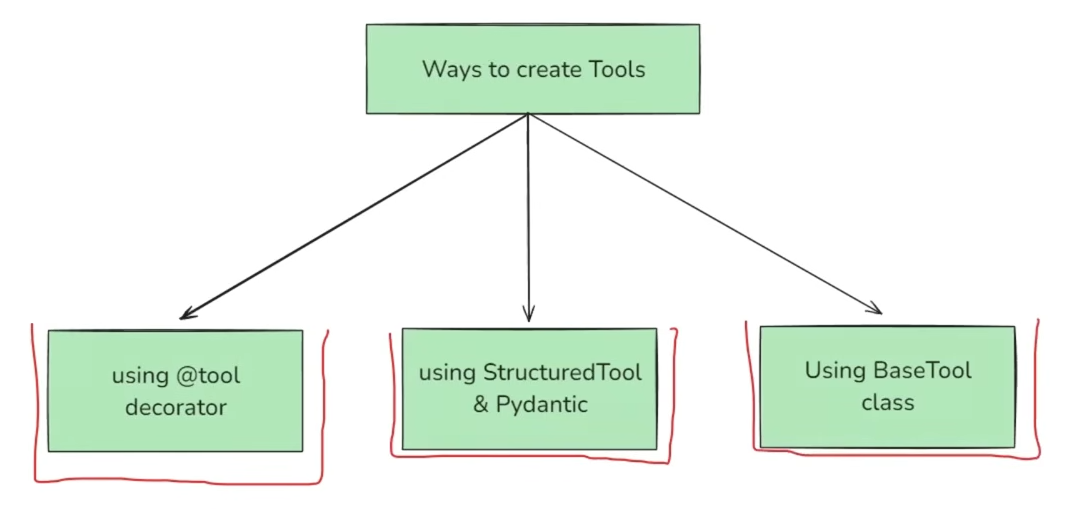

#### using tool operator

In [7]:
from langchain_core.tools import tool

In [8]:
# Step 1 - create a function

def multiply(a, b):
    """Multiply two numbers"""
    return a*b

In [9]:
# Step 2 - add type hints

def multiply(a: int, b:int) -> int:
    """Multiply two numbers"""
    return a*b

In [10]:
# Step 3 - add tool decorator

@tool
def multiply(a: int, b:int) -> int:
    """Multiply two numbers"""
    return a*b

In [11]:
result = multiply.invoke({"a":3, "b":5})

In [12]:
result

15

In [13]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [14]:
print(multiply.args_schema.model_json_schema())

{'description': 'Multiply two numbers', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


#### structured tool using pydantic model

In [3]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel, Field

In [4]:
class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

C:\Users\iampr\AppData\Local\Temp\ipykernel_7084\3279971488.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  a: int = Field(required=True, description="The first number to add")
C:\Users\iampr\AppData\Local\Temp\ipykernel_7084\3279971488.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  b: int = Field(required=True, description="The second number to add")


In [5]:
def multiply_func(a:int, b:int) -> int:
    return a*b

In [6]:
multiply_tool = StructuredTool.from_function(
    func=multiply_func,
    name='multiply',
    description='multiply 2 numbers',
    args_schema=MultiplyInput
)

In [7]:
result = multiply_tool.invoke({'a':3, 'b':3})

In [10]:
print(result)
print(multiply_tool.name)
print(multiply_tool.description)
print(multiply_tool.args)

9
multiply
multiply 2 numbers
{'a': {'description': 'The first number to add', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'title': 'B', 'type': 'integer'}}


### 3. Using BaseTool class

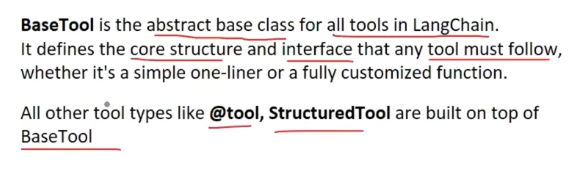

In [11]:
from langchain.tools import BaseTool
from typing import Type

In [12]:
# arg schema using pydantic

class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

C:\Users\iampr\AppData\Local\Temp\ipykernel_7084\908171234.py:4: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  a: int = Field(required=True, description="The first number to add")
C:\Users\iampr\AppData\Local\Temp\ipykernel_7084\908171234.py:5: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  b: int = Field(required=True, description="The second number to add")


In [13]:
class MultiplyTool(BaseTool):
    name: str = "multiply"
    description: str = "Multiply two numbers"

    args_schema: Type[BaseModel] = MultiplyInput

    def _run(self, a: int, b: int) -> int:
        return a * b

In [14]:
multiply_tool = MultiplyTool()

In [15]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)

print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'title': 'B', 'type': 'integer'}}


### 4. Tookits

In [18]:
from langchain_core.tools import tool

# Custom tools
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b

In [19]:
class MathToolkit:
    def get_tools(self):
        return [add, multiply]

In [20]:
toolkit = MathToolkit()
tools = toolkit.get_tools()

for tool in tools:
    print(tool.name, "=>", tool.description)

add => Add two numbers
multiply => Multiply two numbers
